# Assignment

In [21]:
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
print("Device: ", DEVICE)

Device:  cpu


## Configs and Class list


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
DATA_DIR = Path('/content/drive/MyDrive/be-mlsys-assignment-dataset')
CANDIDATE_DIR = DATA_DIR / 'candidate_tiles'
EVAL_DIR = DATA_DIR / 'eval_set'
EVAL_LABELS_CSV = DATA_DIR / 'eval_labels.csv'

CLASSES = sorted([p.name for p in CANDIDATE_DIR.iterdir() if p.is_dir()])
print(f"No. of classes: {len(CLASSES)}")

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

No. of classes: 7


## File list + stratified train/val split

In [25]:
records = []

for cls in CLASSES:
    for img_path in sorted((CANDIDATE_DIR / cls).glob("*.png")):
        records.append({"path": str(img_path), "label": cls})


df = pd.DataFrame(records)
print("Total candidate tiles: ", len(df))
print(df["label"].value_counts())

Total candidate tiles:  1050
label
AnnualCrop     150
Forest         150
Highway        150
Industrial     150
Residential    150
River          150
SeaLake        150
Name: count, dtype: int64


## Train test val split

In [26]:
train_df, val_df = train_test_split(df, test_size = 0.2, stratify = df['label'], random_state = SEED)

print("Train: ", len(train_df), "Val: ", len(val_df))

Train:  840 Val:  210


## Dataset class + transforms (128  * 128)

In [27]:
IMG_SIZE = 128

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [28]:
class TileDataset(Dataset):
  def __init__(self, dataframe, transform, has_labels = True):
      self.df = dataframe.reset_index(drop = True)
      self.transform = transform
      self.has_labels = has_labels


  def __len__(self):
      return len(self.df)


  def __getitem__(self, idx):
      row = self.df.iloc[idx]
      img = Image.open(row['path']).convert('RGB')
      img = self.transform(img)

      if self.has_labels:
          return img, CLASS_TO_IDX[row['label']]

      return img, row['path']

In [29]:
BATCH_SIZE = 32

train_ds = TileDataset(train_df, train_tfms)
val_ds = TileDataset(val_df, eval_tfms)

train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle= True, num_workers = 0)
val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle= False, num_workers= 0)

print("Train batches: ", len(train_loader), "Val batches: ", len(val_loader))

Train batches:  27 Val batches:  7


## Model- MobileNet V3- small, frozen backbone, new head

In [30]:
def build_mobilenetv3_small(num_classes, freeze_backbone = True):
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_small(weights = weights)

    if freeze_backbone:
        for param in model.features.parameters():
          param.requires_grad = False

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


model = build_mobilenetv3_small(num_classes= len(CLASSES), freeze_backbone= True).to(DEVICE)

trainable_params = [p for p in model.classifier.parameters() if p.requires_grad]

print(f"Trainable params: {sum(p.numel() for p in trainable_params):,} "
      f"/ {sum(p.numel() for p in model.parameters()):,} total")

Trainable params: 598,023 / 1,525,031 total


## Train/eval loop

In [31]:
def run_epoch(model, loader, criterion, optimizer = None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                  loss.backward()
                  optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_n += imgs.size(0)

        avg_loss = total_loss / total_n
        avg_acc = total_correct / total_n
        return avg_loss, avg_acc


def train_model(model, train_loader, val_loader, epochs, lr, only_params = None):
    criterion = nn.CrossEntropyLoss()
    params = only_params if only_params is not None else model.parameters()
    optimizer = optim.Adam(params, lr = lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer= None)
        dt = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch}/{epochs} ({dt:.1f}s) | "
              f"train_loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val_loss {val_loss:.4f} acc {val_acc:.3f}")


    return history

## Run training

In [32]:
EPOCHS = 8
LR = 1e-3

history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR,
    only_params=trainable_params,
)

Epoch 1/8 (305.3s) | train_loss 1.0116 acc 0.644 | val_loss 0.9676 acc 0.757
Epoch 2/8 (8.7s) | train_loss 0.4817 acc 0.819 | val_loss 0.6922 acc 0.795
Epoch 3/8 (9.3s) | train_loss 0.4397 acc 0.852 | val_loss 0.5635 acc 0.814
Epoch 4/8 (8.8s) | train_loss 0.4290 acc 0.860 | val_loss 0.4908 acc 0.848
Epoch 5/8 (9.2s) | train_loss 0.3669 acc 0.863 | val_loss 0.4294 acc 0.848
Epoch 6/8 (9.4s) | train_loss 0.3669 acc 0.873 | val_loss 0.4708 acc 0.824
Epoch 7/8 (8.5s) | train_loss 0.3102 acc 0.886 | val_loss 0.4117 acc 0.848
Epoch 8/8 (9.4s) | train_loss 0.2815 acc 0.900 | val_loss 0.4040 acc 0.857


## Plot curves

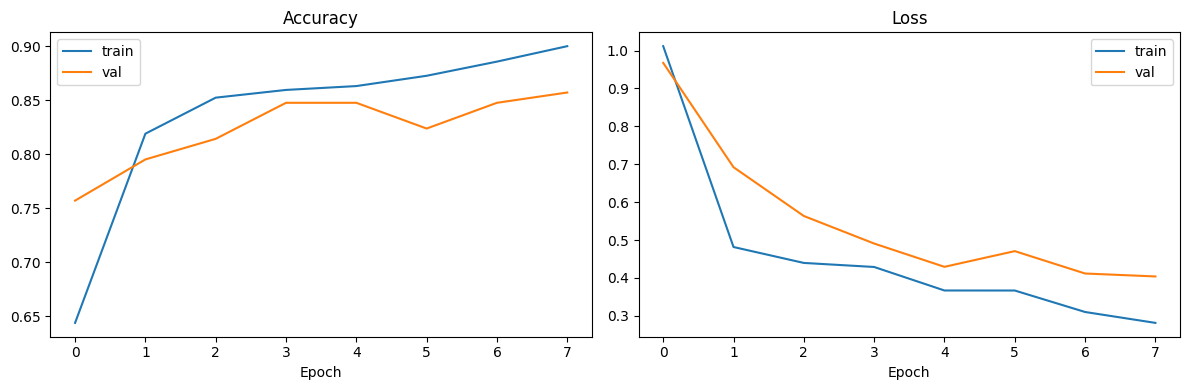

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_acc"], label="train")
axes[0].plot(history["val_acc"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_loss"], label="train")
axes[1].plot(history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Validation evaluation

Validation accuracy: 85.714%
              precision    recall  f1-score   support

  AnnualCrop      0.929     0.867     0.897        30
      Forest      0.853     0.967     0.906        30
     Highway      0.850     0.567     0.680        30
  Industrial      0.763     0.967     0.853        30
 Residential      0.920     0.767     0.836        30
       River      0.778     0.933     0.848        30
     SeaLake      0.966     0.933     0.949        30

    accuracy                          0.857       210
   macro avg      0.865     0.857     0.853       210
weighted avg      0.865     0.857     0.853       210



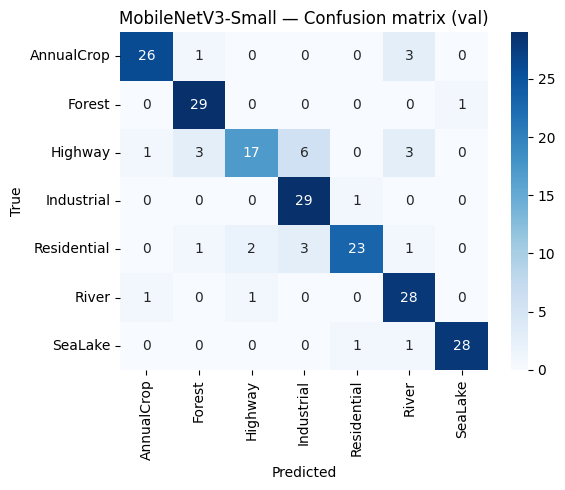

In [34]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_probs = get_predictions(model, val_loader)
acc = accuracy_score(y_true, y_pred)
print(f"Validation accuracy: {acc:.3%}")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("MobileNetV3-Small — Confusion matrix (val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Confidence distribution

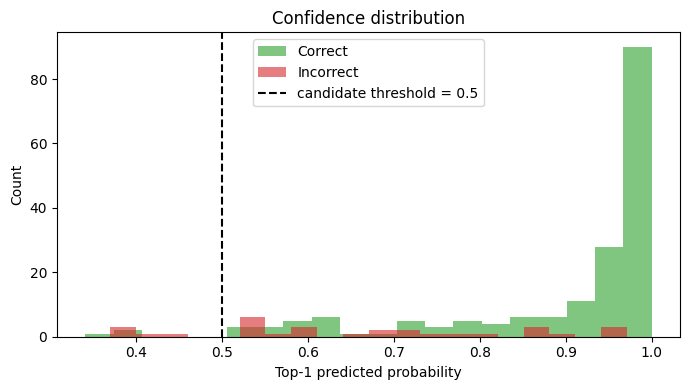

Mean confidence when correct:   0.900
Mean confidence when incorrect: 0.658
threshold=0.3: 100.0% auto-accepted, accuracy among accepted = 85.714%
threshold=0.4: 97.1% auto-accepted, accuracy among accepted = 86.765%
threshold=0.5: 96.2% auto-accepted, accuracy among accepted = 87.624%
threshold=0.6: 87.1% auto-accepted, accuracy among accepted = 91.257%
threshold=0.7: 81.0% auto-accepted, accuracy among accepted = 92.941%
threshold=0.8: 72.9% auto-accepted, accuracy among accepted = 94.771%


In [35]:
top_conf = y_probs.max(axis=1)
correct_mask = (y_true == y_pred)

plt.figure(figsize=(7, 4))
plt.hist(top_conf[correct_mask], bins=20, alpha=0.6, label="Correct", color="tab:green")
plt.hist(top_conf[~correct_mask], bins=20, alpha=0.6, label="Incorrect", color="tab:red")
plt.axvline(0.5, color="black", linestyle="--", label="candidate threshold = 0.5")
plt.title("Confidence distribution")
plt.xlabel("Top-1 predicted probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence when correct:   {top_conf[correct_mask].mean():.3f}")
print(f"Mean confidence when incorrect: {top_conf[~correct_mask].mean():.3f}")

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    accepted = top_conf >= thresh
    if accepted.sum() == 0:
        continue
    acc_accepted = (y_true[accepted] == y_pred[accepted]).mean()
    pct_accepted = accepted.mean()
    print(f"threshold={thresh:.1f}: {pct_accepted:.1%} auto-accepted, "
          f"accuracy among accepted = {acc_accepted:.3%}")


## Final honest evaluation on

In [36]:
eval_labels_df = pd.read_csv(EVAL_LABELS_CSV)
eval_labels_df["path"] = eval_labels_df["filename"].apply(lambda f: str(EVAL_DIR / f))
eval_labels_df = eval_labels_df.rename(columns={"true_label": "label"})

eval_ds = TileDataset(eval_labels_df, eval_tfms)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False)

eval_true, eval_pred, eval_probs = get_predictions(model, eval_loader)
final_acc = accuracy_score(eval_true, eval_pred)
print(f"FINAL eval_set accuracy: {final_acc:.3%}")
print(classification_report(eval_true, eval_pred, target_names=CLASSES, digits=3))

FINAL eval_set accuracy: 88.095%
              precision    recall  f1-score   support

  AnnualCrop      0.966     0.933     0.949        30
      Forest      0.871     0.900     0.885        30
     Highway      0.735     0.833     0.781        30
  Industrial      0.853     0.967     0.906        30
 Residential      0.962     0.833     0.893        30
       River      0.885     0.767     0.821        30
     SeaLake      0.933     0.933     0.933        30

    accuracy                          0.881       210
   macro avg      0.886     0.881     0.881       210
weighted avg      0.886     0.881     0.881       210



## Saving artifacts for the API

In [37]:
OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), OUT_DIR / "model.pt")

with open(OUT_DIR / "class_mapping.json", "w") as f:
    json.dump({"class_to_idx": CLASS_TO_IDX, "idx_to_class": IDX_TO_CLASS}, f, indent=2)

config = {
    "model_type": "mobilenet_v3_small_transfer",
    "img_size": IMG_SIZE,
    "normalize_mean": [0.485, 0.456, 0.406],
    "normalize_std": [0.229, 0.224, 0.225],
    "final_eval_accuracy": final_acc,
}
with open(OUT_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved to", OUT_DIR.resolve())

Saved to /content/artifacts


# Inference

In [44]:
import json
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

ARTIFACTS_DIR = Path("artifacts")  # wherever you put model.pt etc.

# ---- load config + class mapping ----
with open(ARTIFACTS_DIR / "model_config.json") as f:
    config = json.load(f)

with open(ARTIFACTS_DIR / "class_mapping.json") as f:
    mapping = json.load(f)

IDX_TO_CLASS = {int(k): v for k, v in mapping["idx_to_class"].items()}
NUM_CLASSES = len(IDX_TO_CLASS)
IMG_SIZE = config["img_size"]

# ---- rebuild the exact architecture used in training ----
def build_mobilenetv3_small(num_classes):
    model = models.mobilenet_v3_small(weights=None)  # no download needed, we're loading our own weights
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_mobilenetv3_small(NUM_CLASSES)
model.load_state_dict(torch.load(ARTIFACTS_DIR / "model.pt", map_location="cpu"))
model.eval()

# ---- same eval-time transform used in training ----
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=config["normalize_mean"], std=config["normalize_std"]),
])

def predict(image_path):
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)  # add batch dim

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]

    top_idx = probs.argmax().item()
    predicted_class = IDX_TO_CLASS[top_idx]
    confidence = probs[top_idx].item()
    class_probs = {IDX_TO_CLASS[i]: round(probs[i].item(), 4) for i in range(NUM_CLASSES)}

    return {
        "predicted_class": predicted_class,
        "confidence": round(confidence, 4),
        "class_probs": class_probs,
        "needs_review": confidence < 0.5,  # swap in your chosen threshold from the sweep table
    }

# ---- try it ----
result = predict("tile_075.png")
print(json.dumps(result, indent=2))


{
  "predicted_class": "Residential",
  "confidence": 0.5648,
  "class_probs": {
    "AnnualCrop": 0.0044,
    "Forest": 0.0001,
    "Highway": 0.0055,
    "Industrial": 0.4226,
    "Residential": 0.5648,
    "River": 0.0022,
    "SeaLake": 0.0005
  },
  "needs_review": false
}
